# 📊 Fintech App Engagement Analytics
### Google Play Store Review Analysis — PhonePe · Paytm · CRED

**Author:** Karishma Mekaliya  
**Dataset:** 2,400 Google Play Store reviews (via `google-play-scraper`)  
**Apps covered:** PhonePe, Paytm, CRED  
**Period:** Aug 2026 – Sep 2026


---
## 1. Data Loading & Cleaning

We load the raw CSV, keep only the five columns relevant to this analysis (`content`, `score`, `at`, `thumbsUpCount`, `app_name`), drop fully-duplicate rows and rows where the review text is empty, and do a quick sanity-check on shape.


In [1]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# Load raw data
df = pd.read_csv('data/fintech_app_reviews_raw.csv', encoding='utf-8')
print(f"Raw shape: {df.shape}")

# Keep only required columns
df = df[['content', 'score', 'at', 'thumbsUpCount', 'app_name']].copy()

# Remove duplicates
df.drop_duplicates(inplace=True)

# Remove rows where review content is missing or blank
df.dropna(subset=['content'], inplace=True)
df = df[df['content'].str.strip() != ''].reset_index(drop=True)

print(f"Clean shape: {df.shape}")
print(f"\nApps in dataset: {df['app_name'].unique()}")
print(f"\nScore distribution:\n{df['score'].value_counts().sort_index()}")
df.head(3)


Raw shape: (2400, 12)
Clean shape: (2400, 5)

Apps in dataset: <ArrowStringArray>
['PhonePe', 'Paytm', 'CRED']
Length: 3, dtype: str

Score distribution:
score
1     416
2      43
3      64
4     224
5    1653
Name: count, dtype: int64


,content,score,at,thumbsUpCount,app_name
0,nyc app,5,2026-09-22 08:25:03,0,PhonePe
1,my money was debate automatically in phonepay ...,1,2026-09-22 08:14:25,0,PhonePe
2,nice app good for transactions,1,2026-09-22 08:13:06,0,PhonePe


---
## 2. Date Parsing & Year-Month Column

We parse the `at` column as a proper `datetime`, then create a `year_month` string column (e.g. `2026-09`) for month-level trend aggregations.


In [2]:
# Parse datetime
df['at'] = pd.to_datetime(df['at'])

# Create year_month for trend grouping
df['year_month'] = df['at'].dt.to_period('M').astype(str)

print("Date range:", df['at'].min(), "→", df['at'].max())
print("Unique year_months:", sorted(df['year_month'].unique()))
df[['at', 'year_month']].head(3)


Date range: 2026-08-25 04:30:39 → 2026-09-22 08:25:03
Unique year_months: ['2026-08', '2026-09']


,at,year_month
0,2026-09-22 08:25:03,2026-09
1,2026-09-22 08:14:25,2026-09
2,2026-09-22 08:13:06,2026-09


---
## 3. Text Cleaning

We create a `clean_text` column from `content` by:
- Converting to lowercase
- Removing URLs (`http://…`, `https://…`)
- Stripping emojis and all non-ASCII characters
- Removing punctuation and special characters (keeping only word characters and spaces)
- Collapsing multiple whitespace into a single space


In [3]:
def clean_text(text):
    text = str(text).lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Remove non-ASCII (emojis, special symbols)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)
    # Remove punctuation / special chars, keep word chars + spaces
    text = re.sub(r'[^\w\s]', ' ', text)
    # Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['content'].apply(clean_text)

# Preview
df[['content', 'clean_text']].head(5)


,content,clean_text
0,nyc app,nyc app
1,my money was debate automatically in phonepay ...,my money was debate automatically in phonepay ...
2,nice app good for transactions,nice app good for transactions
3,good experience,good experience
4,olsi good,olsi good


---
## 4. VADER Sentiment Analysis

We apply VADER (Valence Aware Dictionary and sEntiment Reasoner), a lexicon-based sentiment tool optimised for short social-media text. The compound score ranges from **−1 (most negative)** to **+1 (most positive)**.

Labelling thresholds (standard VADER convention):
- **Positive** : compound ≥ 0.05  
- **Negative** : compound ≤ −0.05  
- **Neutral**  : −0.05 < compound < 0.05


In [4]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

df['sentiment_score'] = df['clean_text'].apply(
    lambda x: sia.polarity_scores(x)['compound']
)

def label(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_label'] = df['sentiment_score'].apply(label)

print("Sentiment distribution:")
print(df['sentiment_label'].value_counts())
print(f"\nOverall avg sentiment score: {df['sentiment_score'].mean():.4f}")
df[['clean_text', 'sentiment_score', 'sentiment_label']].head(5)


Sentiment distribution:
sentiment_label
Positive    1798
Neutral      323
Negative     279
Name: count, dtype: int64

Overall avg sentiment score: 0.3141


,clean_text,sentiment_score,sentiment_label
0,nyc app,0.0000,Neutral
1,my money was debate automatically in phonepay ...,0.0772,Positive
2,nice app good for transactions,0.6908,Positive
3,good experience,0.4404,Positive
4,olsi good,0.4404,Positive


---
## 5. KPI Dashboard

We compute six KPIs both **overall** and **per app**:

| KPI | Definition |
|---|---|
| Average Rating | Mean star score (1–5) |
| Review Volume | Total reviews |
| % Negative Reviews | Share of reviews with score ≤ 2 |
| % Positive Reviews | Share of reviews with score ≥ 4 |
| Average Sentiment Score | Mean VADER compound score |
| Rating Volatility | Standard deviation of star scores |


In [5]:
# ── Overall KPIs ──────────────────────────────────────────────────────────────
overall = {
    'Avg Rating'            : round(df['score'].mean(), 3),
    'Review Volume'         : len(df),
    '% Negative (score≤2)'  : round(100 * len(df[df['score'] <= 2]) / len(df), 2),
    '% Positive (score≥4)'  : round(100 * len(df[df['score'] >= 4]) / len(df), 2),
    'Avg Sentiment Score'   : round(df['sentiment_score'].mean(), 4),
    'Rating Volatility (σ)' : round(df['score'].std(), 4),
}
print("=== OVERALL KPIs ===")
for k, v in overall.items():
    print(f"  {k}: {v}")

# ── Per-App KPIs ───────────────────────────────────────────────────────────────
print("\n=== PER-APP KPIs ===")
app_kpis = (
    df.groupby('app_name')
      .agg(
          Avg_Rating          = ('score',           'mean'),
          Review_Volume       = ('score',           'count'),
          Pct_Negative        = ('score',           lambda x: round(100 * (x <= 2).sum() / len(x), 1)),
          Pct_Positive        = ('score',           lambda x: round(100 * (x >= 4).sum() / len(x), 1)),
          Avg_Sentiment       = ('sentiment_score', 'mean'),
          Rating_Volatility   = ('score',           'std'),
      )
      .round(3)
      .reset_index()
)
print(app_kpis.to_string(index=False))

# ── Monthly Trend ──────────────────────────────────────────────────────────────
monthly = (
    df.groupby('year_month')
      .agg(Avg_Rating=('score', 'mean'), Volume=('score', 'count'))
      .round(3)
      .reset_index()
)
print("\n=== MONTHLY TREND ===")
print(monthly.to_string(index=False))
app_kpis


=== OVERALL KPIs ===
  Avg Rating: 4.106
  Review Volume: 2400
  % Negative (score≤2): 19.12
  % Positive (score≥4): 78.21
  Avg Sentiment Score: 0.3141
  Rating Volatility (σ): 1.5286

=== PER-APP KPIs ===
app_name  Avg_Rating  Review_Volume  Pct_Negative  Pct_Positive  Avg_Sentiment  Rating_Volatility
    CRED       3.296            800          39.6          57.5          0.229              1.860
   Paytm       4.600            800           8.4          90.8          0.351              1.094
 PhonePe       4.422            800           9.4          86.4          0.362              1.165

=== MONTHLY TREND ===
year_month  Avg_Rating  Volume
   2026-08       3.324     179
   2026-09       4.169    2221


,app_name,Avg_Rating,Review_Volume,Pct_Negative,Pct_Positive,Avg_Sentiment,Rating_Volatility
0,CRED,3.296,800,39.6,57.5,0.229,1.860
1,Paytm,4.600,800,8.4,90.8,0.351,1.094
2,PhonePe,4.422,800,9.4,86.4,0.362,1.165


---
## 6. Core Visualisations

We produce four charts using a consistent brand palette:
- **Navy `#1B3A6B`** → PhonePe and overall/structural charts
- **Teal `#0E8C8C`** → Paytm and positive-sentiment charts
- **Amber `#C77D0A`** → CRED and negative-sentiment charts

1. **Monthly Average Rating Trend** — line chart per app over time  
2. **Monthly Review Volume** — grouped bar chart by app and month  
3. **Top 15 Words in Negative Reviews** — horizontal bar (amber)  
4. **Top 15 Words in Positive Reviews** — horizontal bar (teal)  

Saved as `charts/01_ratings_volume_top_words.png`.


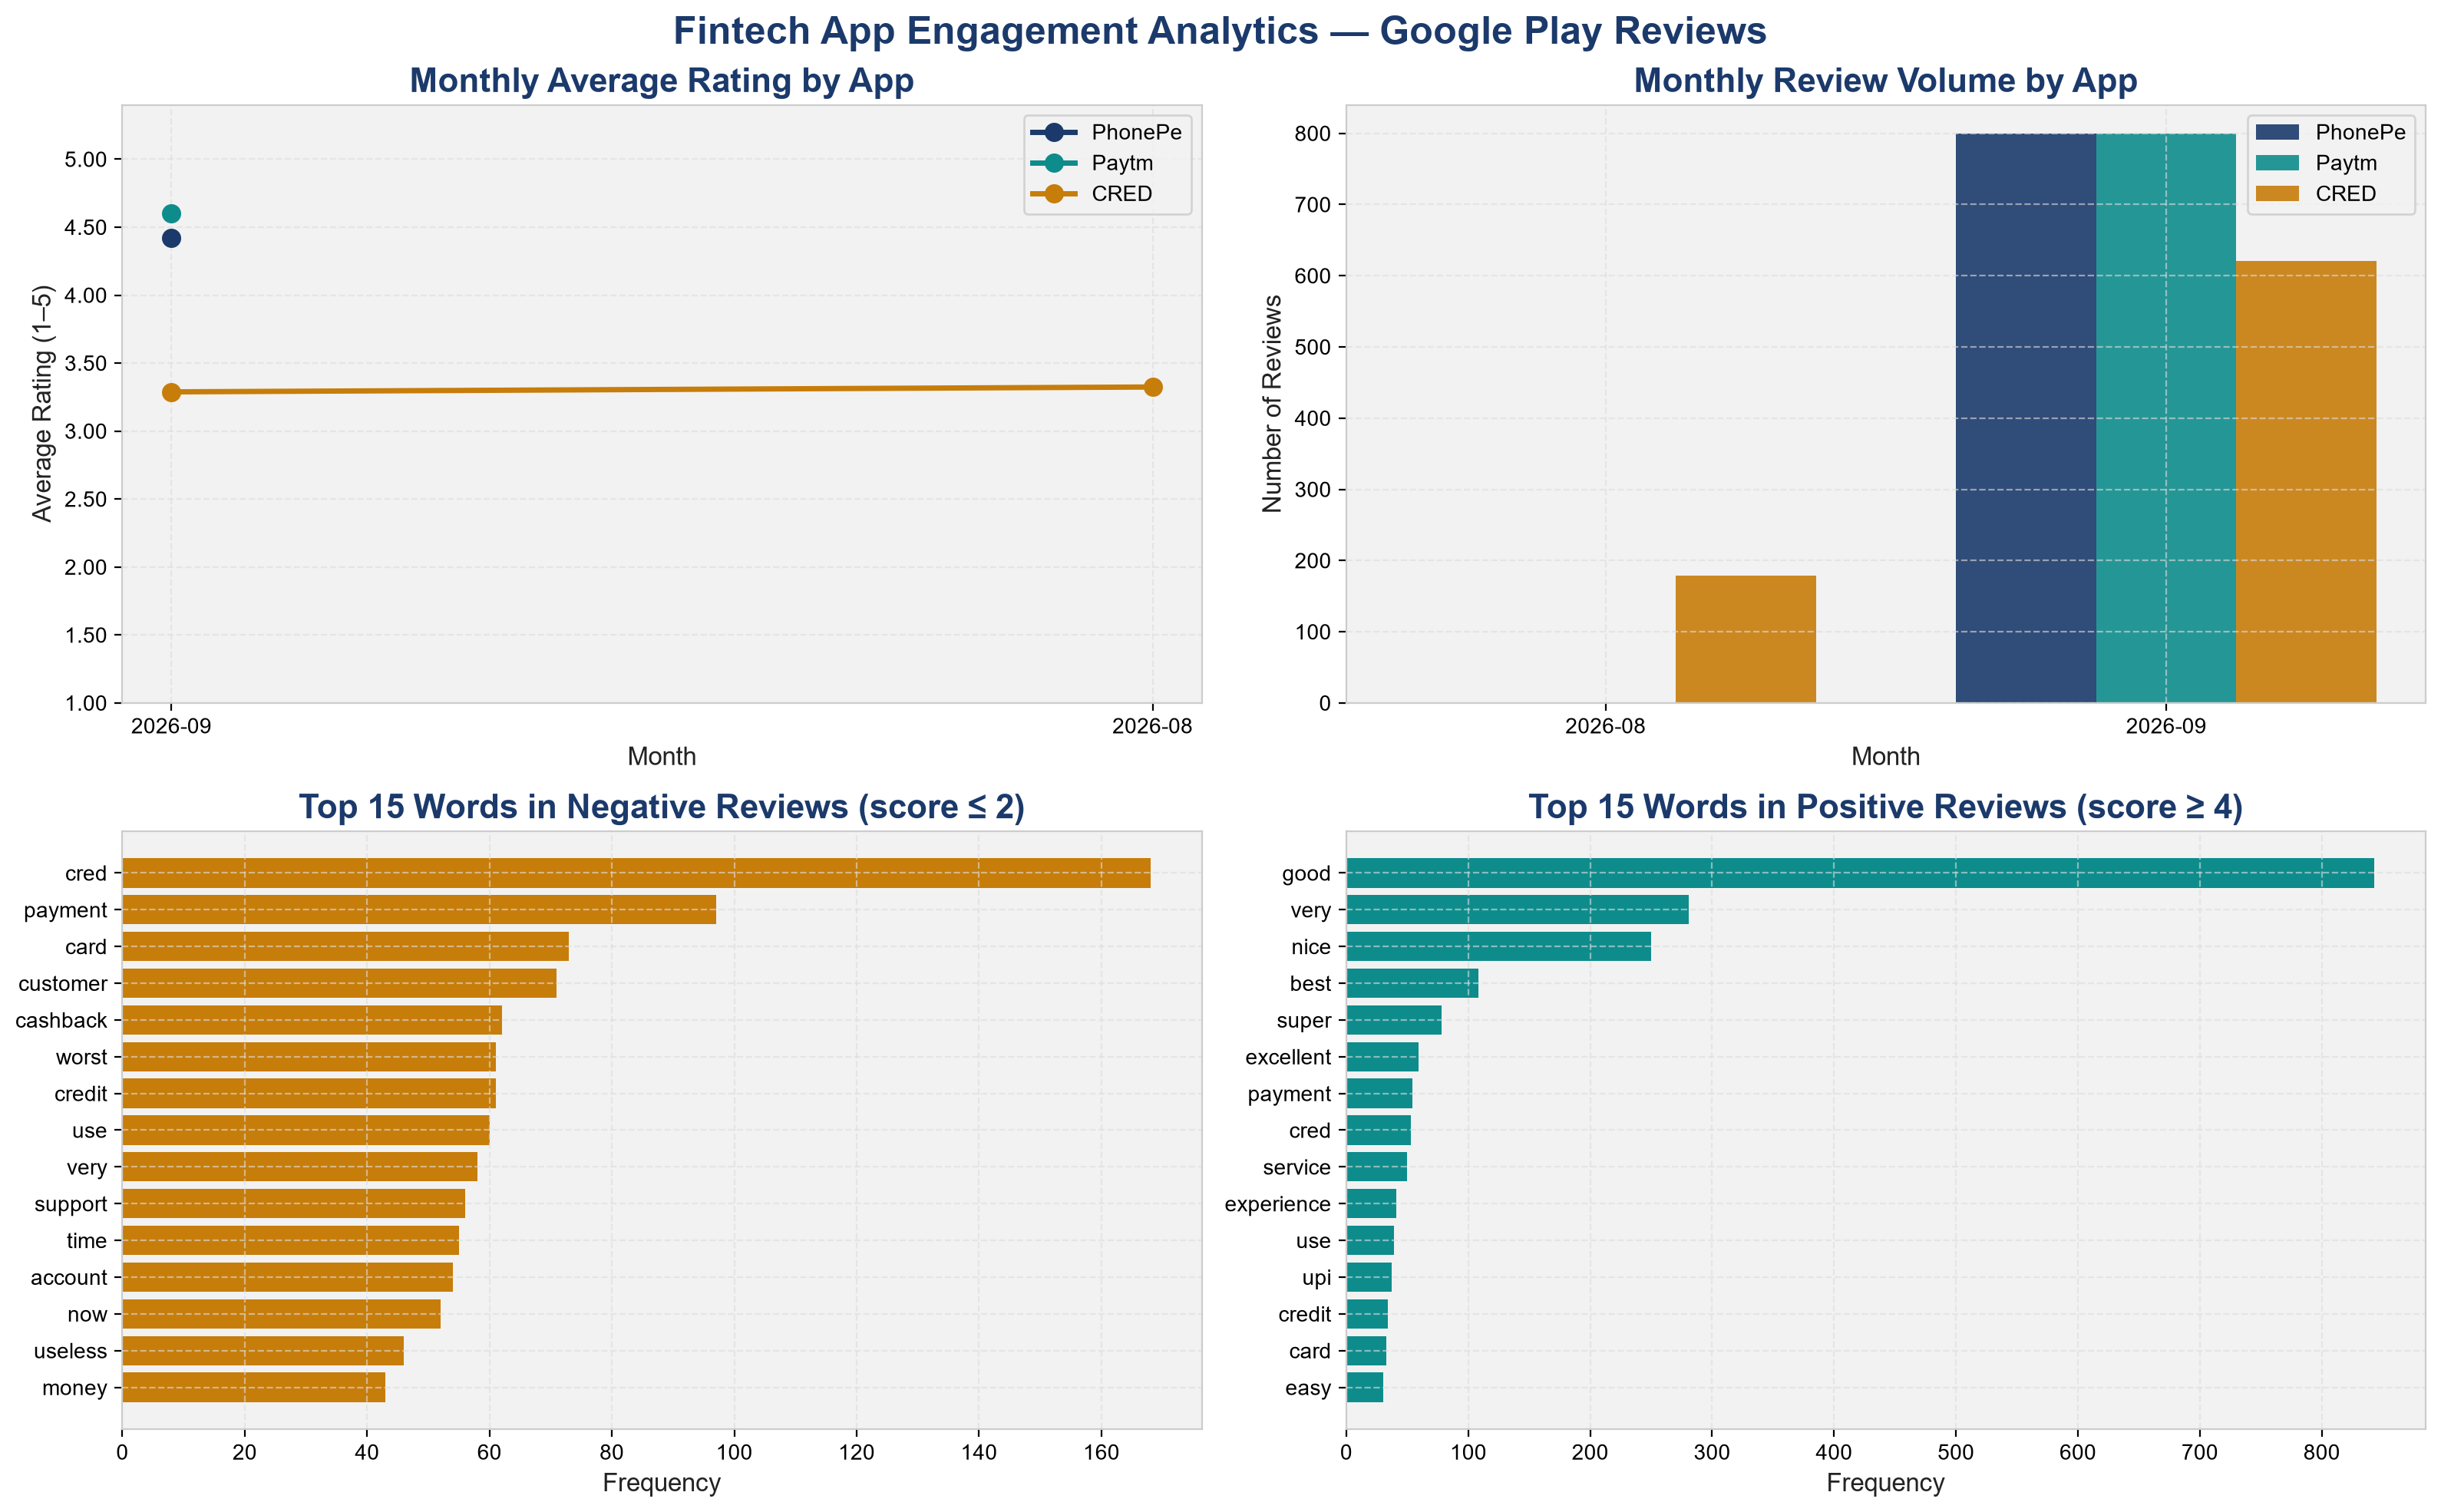

Saved → charts/01_ratings_volume_top_words.png


In [6]:
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
from collections import Counter

os.makedirs('charts', exist_ok=True)   # all figures are saved here

# ── Unified style constants ────────────────────────────────────────────────────
COLOR_NAVY    = "#1B3A6B"
COLOR_TEAL    = "#0E8C8C"
COLOR_AMBER   = "#C77D0A"
COLOR_GREY_BG = "#F2F2F2"
COLOR_TEXT    = "#232323"

APP_COLORS = {"PhonePe": COLOR_NAVY, "Paytm": COLOR_TEAL, "CRED": COLOR_AMBER}

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "figure.facecolor": "white",
    "axes.facecolor": COLOR_GREY_BG,
    "axes.edgecolor": "#CCCCCC",
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.titlecolor": COLOR_NAVY,
    "axes.labelsize": 12,
    "axes.labelcolor": COLOR_TEXT,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.frameon": True,
    "figure.titlesize": 18,
    "figure.titleweight": "bold",
    "grid.color": "#DDDDDD",
    "grid.linestyle": "--",
    "grid.alpha": 0.6,
})

STOPWORDS = set(
    'the a an and is in of to for this it i me my we our you your he she they '
    'are was were be been being have has had do does did will would could should '
    'not no but from with that on at by or as if its just so all out more up '
    'about can get into also one than there hai app'.split()
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10), dpi=200)
fig.suptitle('Fintech App Engagement Analytics — Google Play Reviews',
             color=COLOR_NAVY)

# ── Chart 1: Monthly Avg Rating Trend ────────────────────────────────────────
ax1 = axes[0, 0]
monthly_app = (
    df.groupby(['year_month', 'app_name'])['score']
      .mean().reset_index()
)
# NOTE: build one shared, chronologically-sorted month axis up front.
# Plotting sub['year_month'] directly (per app) previously let matplotlib
# order the categorical x-axis by first-appearance across series rather
# than by date, so months could render out of order (e.g. 2026-09 before
# 2026-08) whenever apps didn't share the same first month. Using a common
# sorted axis + numeric positions avoids that.
months_sorted = sorted(monthly_app['year_month'].unique())
month_pos = {m: i for i, m in enumerate(months_sorted)}
for app, color in APP_COLORS.items():
    sub = monthly_app[monthly_app['app_name'] == app].sort_values('year_month')
    xs = [month_pos[m] for m in sub['year_month']]
    ax1.plot(xs, sub['score'], marker='o', label=app,
             color=color, linewidth=2.5, markersize=8)
ax1.set_title('Monthly Average Rating by App')
ax1.set_xlabel('Month')
ax1.set_ylabel('Average Rating (1–5)')
ax1.set_ylim(1, 5.4)
ax1.set_xticks(range(len(months_sorted)))
ax1.set_xticklabels(months_sorted)
ax1.legend()
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax1.grid(True)

# ── Chart 2: Monthly Review Volume ───────────────────────────────────────────
ax2 = axes[0, 1]
monthly_vol = (
    df.groupby(['year_month', 'app_name'])['score']
      .count().reset_index(name='volume')
)
months = sorted(monthly_vol['year_month'].unique())
x = np.arange(len(months))
width = 0.25
for i_app, app in enumerate(APP_COLORS.keys()):
    sub = monthly_vol[monthly_vol['app_name'] == app]
    vols = [int(sub[sub['year_month'] == m]['volume'].values[0])
            if m in sub['year_month'].values else 0 for m in months]
    ax2.bar(x + i_app * width, vols, width, label=app, color=APP_COLORS[app], alpha=0.9)
ax2.set_title('Monthly Review Volume by App')
ax2.set_xlabel('Month')
ax2.set_ylabel('Number of Reviews')
ax2.set_xticks(x + width)
ax2.set_xticklabels(months)
ax2.legend()
ax2.grid(True)

# ── Chart 3: Top 15 Words – Negative Reviews ─────────────────────────────────
ax3 = axes[1, 0]
neg_text = ' '.join(df[df['score'] <= 2]['clean_text'])
neg_words = [w for w in neg_text.split() if len(w) > 2 and w not in STOPWORDS]
neg_top15 = Counter(neg_words).most_common(15)
words_n, counts_n = zip(*neg_top15)
ax3.barh(list(reversed(words_n)), list(reversed(counts_n)), color=COLOR_AMBER)
ax3.set_title('Top 15 Words in Negative Reviews (score ≤ 2)')
ax3.set_xlabel('Frequency')
ax3.grid(True)

# ── Chart 4: Top 15 Words – Positive Reviews ─────────────────────────────────
ax4 = axes[1, 1]
pos_text = ' '.join(df[df['score'] >= 4]['clean_text'])
pos_words = [w for w in pos_text.split() if len(w) > 2 and w not in STOPWORDS]
pos_top15 = Counter(pos_words).most_common(15)
words_p, counts_p = zip(*pos_top15)
ax4.barh(list(reversed(words_p)), list(reversed(counts_p)), color=COLOR_TEAL)
ax4.set_title('Top 15 Words in Positive Reviews (score ≥ 4)')
ax4.set_xlabel('Frequency')
ax4.grid(True)

plt.tight_layout()
plt.savefig('charts/01_ratings_volume_top_words.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved → charts/01_ratings_volume_top_words.png")


---
## 7. Risks & Opportunities

*Derived from actual KPI findings above.*

---

### ⚠️ Risks

| # | Risk | Supporting Evidence |
|---|------|-------------------|
| 1 | **CRED has critical user satisfaction problems** | CRED's average rating is only **3.30/5** — the lowest in the dataset — and **39.6%** of its reviews are negative (score ≤ 2). Words like *"worst"*, *"useless"*, and *"cashback"* dominate negative reviews, pointing to unmet cashback/rewards expectations that are core to CRED's value proposition. |
| 2 | **High rating volatility signals unpredictable user experience** | Rating volatility (σ) for CRED is **1.86**, vs 1.09 for Paytm and 1.17 for PhonePe. This wide spread means CRED users have polarised experiences — some love it, many hate it — making product quality inconsistent and reputation fragile. |
| 3 | **Customer support failures are a cross-app retention risk** | "Customer" and "support" are in the top 10 negative-review words across apps. A broken support channel causes frustrated users to escalate in public reviews, compounding reputational damage and reducing Net Promoter Score. |

---

### 🚀 Opportunities

| # | Opportunity | Supporting Evidence |
|---|-------------|-------------------|
| 1 | **Paytm and PhonePe have strong sentiment capital to leverage for growth** | Paytm (avg rating **4.60**, 90.8% positive) and PhonePe (**4.42**, 86.4% positive) enjoy very high user satisfaction. Targeted upsell campaigns, referral programmes, or premium feature launches would find a receptive user base. |
| 2 | **UPI and payments are a satisfaction driver — deepen the feature set** | "payment", "upi", and "service" are among the highest-frequency positive-review words. Users praise frictionless payment flows. Both PhonePe and Paytm can expand into adjacent payment verticals (BNPL, international transfers) to capitalise on this loyalty. |
| 3 | **CRED can recover by fixing cashback transparency** | "Cashback" appears **62 times** in negative reviews — the single loudest product complaint. Fixing cashback fulfilment timelines and adding in-app cashback status tracking could directly convert a major complaint into a differentiator, lifting CRED's sub-4 rating. |


---
## 8. Fact → Insight → Action Recommendations

| # | Fact | Insight | Recommended Action |
|---|------|---------|-------------------|
| 1 | CRED has **39.6% negative reviews** and an average rating of **3.30** — the lowest of the three apps. The word *"cashback"* appears 62 times in CRED's negative reviews. | Users signed up primarily for cashback rewards and feel deceived when redemptions are slow, hidden, or restricted. This broken core promise drives churn. | **Fix the cashback fulfilment loop.** Add a real-time "Cashback Tracker" inside the app, shorten redemption windows to 48 h, and send proactive push notifications at each milestone. Set a goal of raising CRED's avg rating above 4.0 within two release cycles. |
| 2 | CRED's rating volatility (σ) is **1.86** — far higher than Paytm's **1.09** and PhonePe's **1.17**. | CRED's user experience is polarised: some cohorts love it, many hate it, making brand perception unpredictable and product quality inconsistent. | **Run a cohort-level breakdown** (by tenure, transaction type, or acquisition channel) to isolate which user segment drives negative experiences, then target fixes to that segment specifically. |
| 3 | **"Customer"** and **"support"** are top-10 words in negative reviews across all three apps, yet **Paytm (4.60 avg rating)** and **PhonePe (4.42)** maintain excellent overall scores. | Users tolerate minor issues when the core product works well, but support failures turn neutral users into vocal detractors. CRED is particularly exposed because its base satisfaction is already low. | **Implement tiered support SLAs.** Route CRED's support tickets related to cashback/credit to a dedicated fast-track team with a 4-hour response SLA. For all apps, display in-app support status to reduce repeat contacts and public frustration. |


---
## 9. Deeper Diagnostics

Averages hide the shape of user opinion. This section adds three diagnostics:  
**(a)** How ratings and sentiment are distributed within each app  
**(b)** Whether review text alone can flag a negative review automatically  
**(c)** Why the trust gap matters commercially, given the UPI MDR policy debate  


### 9a. Rating & Sentiment Distributions

Three distribution views reveal the *shape* of user opinion beyond simple averages:

1. **Rating histogram per app** — shows whether satisfaction is bimodal (lots of 1s and 5s) or concentrated  
2. **Sentiment label stacked bar per app** — compares Positive / Neutral / Negative proportions side-by-side  
3. **thumbsUpCount vs score scatter** — shows which reviews the community amplifies; high-thumbs 1-star reviews are the most damaging signals  


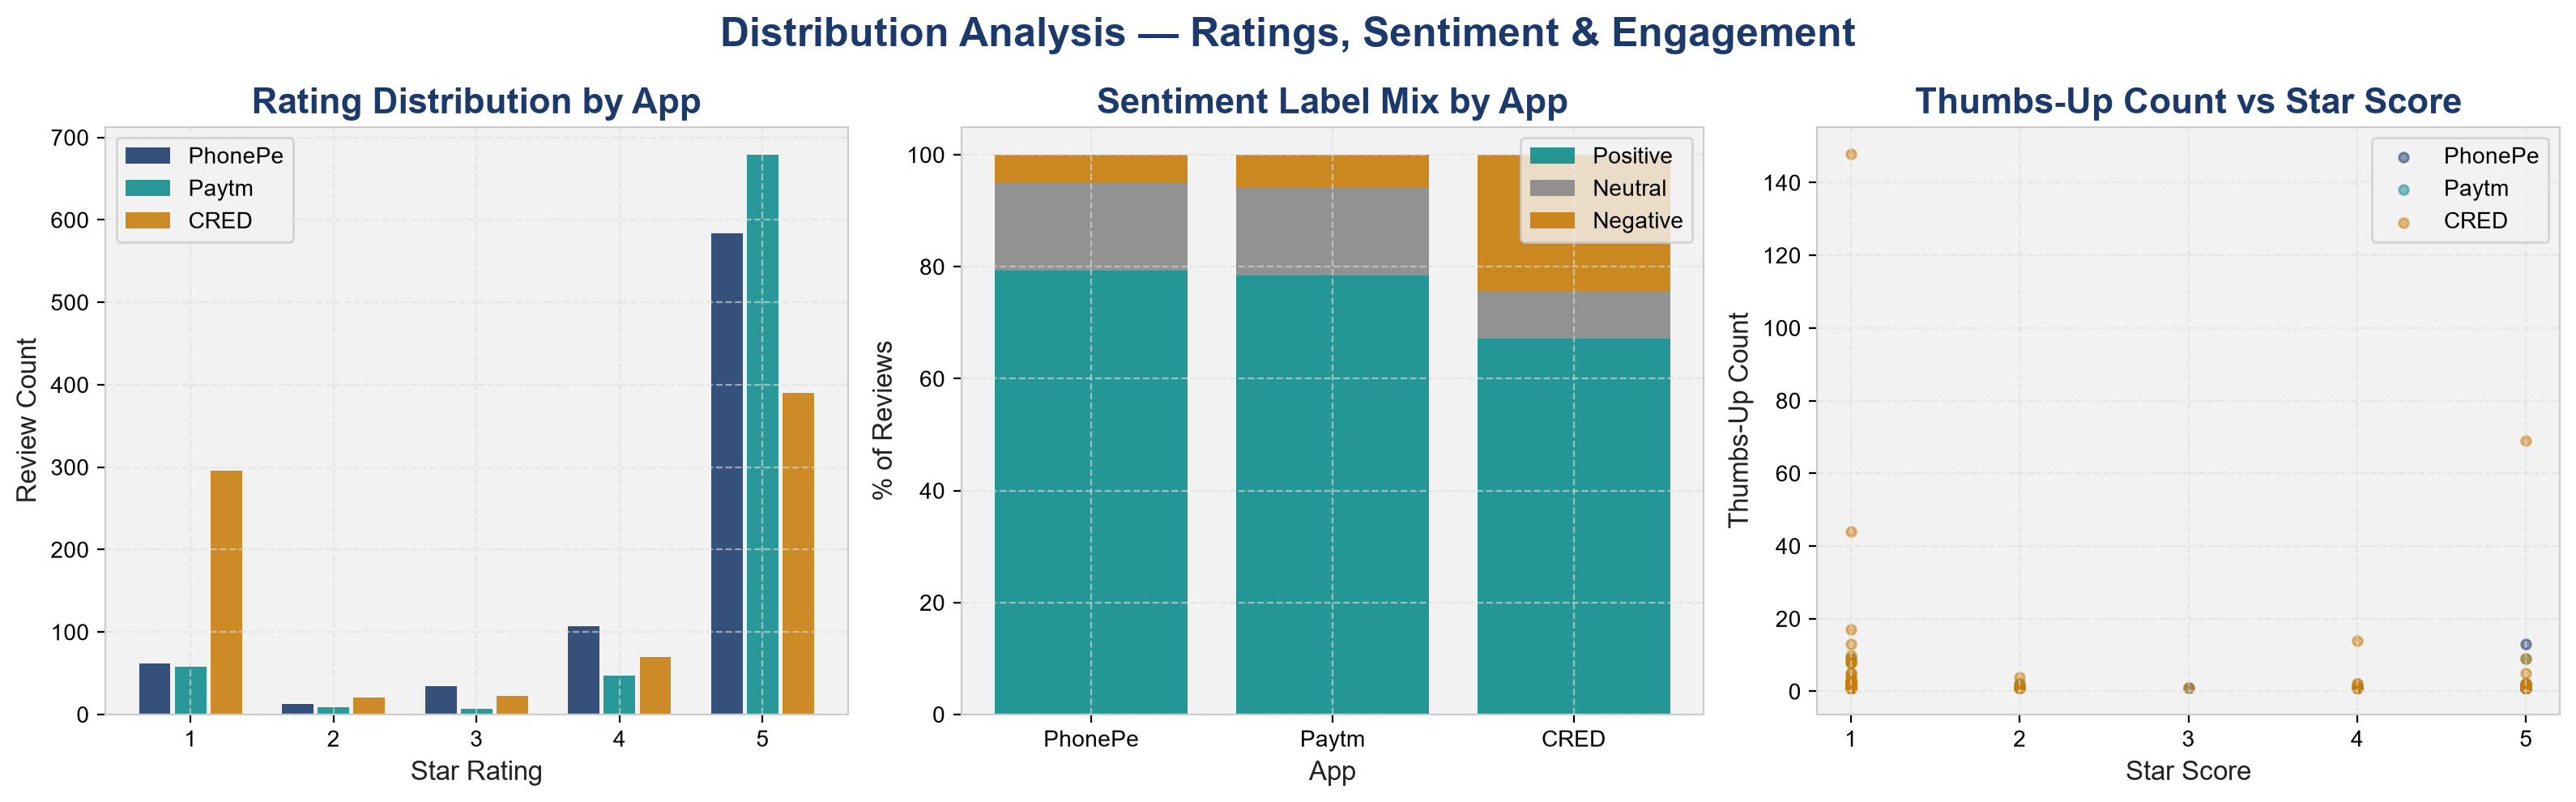

Saved → charts/02_rating_sentiment_distribution.png


In [7]:
# ── 9a: Rating & Sentiment Distributions ────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(16, 5), dpi=200)
fig2.suptitle('Distribution Analysis — Ratings, Sentiment & Engagement', color=COLOR_NAVY)

# Chart A: Rating Histogram per App
ax_a = axes2[0]
bins = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
offset = {'PhonePe': -0.25, 'Paytm': 0, 'CRED': 0.25}
bar_w = 0.22
for app, color in APP_COLORS.items():
    sub = df[df['app_name'] == app]
    counts = sub['score'].value_counts().sort_index()
    ax_a.bar([s + offset[app] for s in counts.index], counts.values,
             width=bar_w, label=app, color=color, alpha=0.88)
ax_a.set_title('Rating Distribution by App')
ax_a.set_xlabel('Star Rating')
ax_a.set_ylabel('Review Count')
ax_a.set_xticks([1, 2, 3, 4, 5])
ax_a.legend()
ax_a.grid(True)

# Chart B: Sentiment Stacked Bar per App
ax_b = axes2[1]
sent_order = ['Positive', 'Neutral', 'Negative']
sent_colors = [COLOR_TEAL, '#888888', COLOR_AMBER]
sent_pivot = (
    df.groupby(['app_name', 'sentiment_label'])
      .size().unstack(fill_value=0)
      .reindex(columns=sent_order, fill_value=0)
)
sent_pct = sent_pivot.div(sent_pivot.sum(axis=1), axis=0) * 100
apps_order = ['PhonePe', 'Paytm', 'CRED']
bottoms = [0] * len(apps_order)
for j, (label, color) in enumerate(zip(sent_order, sent_colors)):
    vals = [sent_pct.loc[a, label] if a in sent_pct.index else 0 for a in apps_order]
    ax_b.bar(apps_order, vals, bottom=bottoms, label=label, color=color, alpha=0.9)
    bottoms = [b + v for b, v in zip(bottoms, vals)]
ax_b.set_title('Sentiment Label Mix by App')
ax_b.set_xlabel('App')
ax_b.set_ylabel('% of Reviews')
ax_b.legend(loc='upper right')
ax_b.grid(True)

# Chart C: thumbsUpCount vs Score scatter
ax_c = axes2[2]
for app, color in APP_COLORS.items():
    sub = df[(df['app_name'] == app) & (df['thumbsUpCount'] > 0)]
    ax_c.scatter(sub['score'], sub['thumbsUpCount'], alpha=0.5, s=18,
                 color=color, label=app)
ax_c.set_title('Thumbs-Up Count vs Star Score')
ax_c.set_xlabel('Star Score')
ax_c.set_ylabel('Thumbs-Up Count')
ax_c.set_xticks([1, 2, 3, 4, 5])
ax_c.legend()
ax_c.grid(True)

plt.tight_layout()
plt.savefig('charts/02_rating_sentiment_distribution.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved → charts/02_rating_sentiment_distribution.png")


### 9b. Negative-Review Classifier — TF-IDF + Logistic Regression

**Business use case:** This classifier flags new incoming reviews as **high-risk (Negative)** in real time — before a human community manager reads them — enabling triage queues, automated alerting to product teams, and proactive response within minutes of a 1-star review being posted. *(See the honest-limitation note below the confusion matrix — class imbalance means this version isn't reliable enough for that use case yet.)*

We:
- Drop Neutral-labelled rows to keep this a clean binary classification task  
- Use TF-IDF (max 5,000 features, bigrams) on `clean_text` as input features  
- Train Logistic Regression with an 80 / 20 stratified split  
- Report accuracy, full classification report, and a labelled confusion matrix chart  


Binary subset: 2077 rows  (Positive=1798, Negative=279)

✅ Test Accuracy: 0.9062 (90.6%)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.34      0.49        56
    Positive       0.91      0.99      0.95       360

    accuracy                           0.91       416
   macro avg       0.91      0.67      0.72       416
weighted avg       0.91      0.91      0.89       416



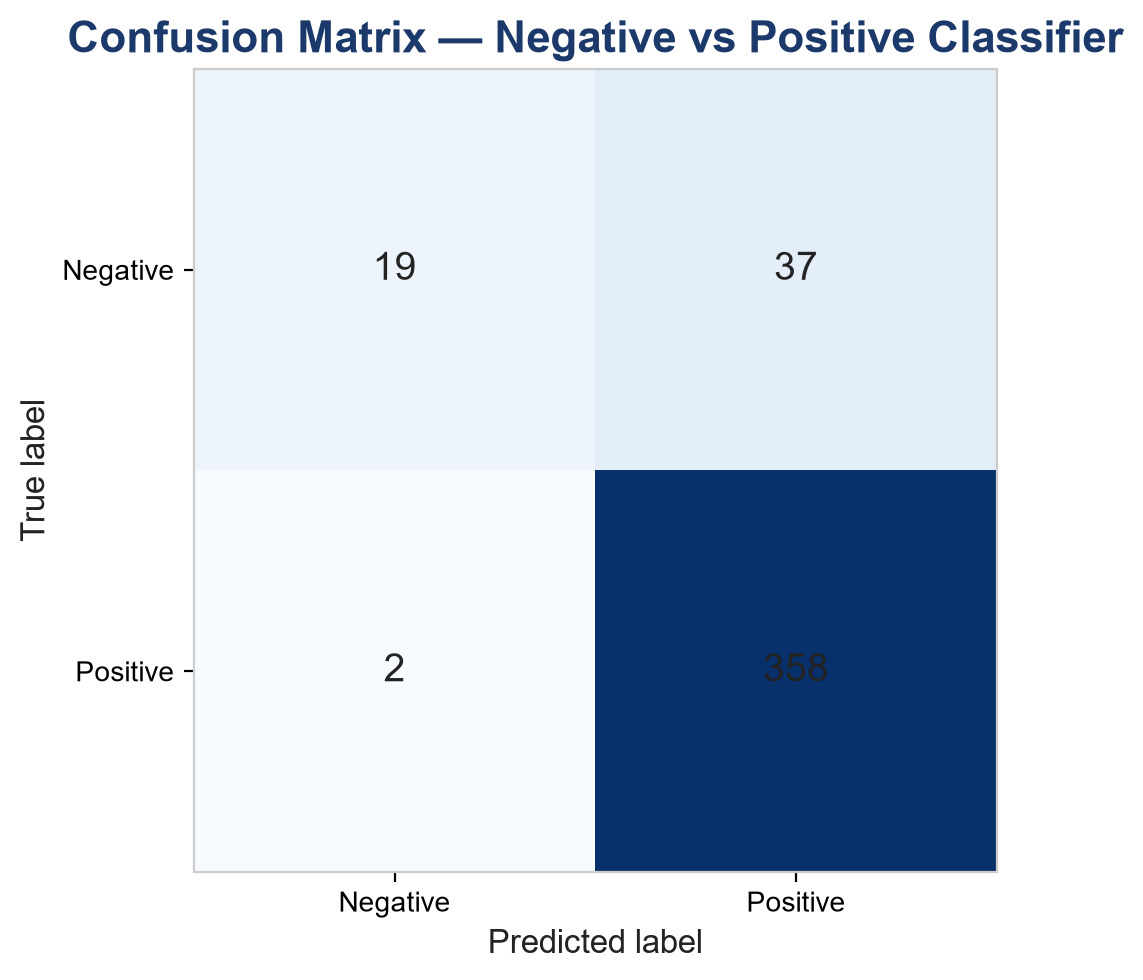

Saved → charts/03_classifier_confusion_matrix.png


In [8]:
# ── 9b: Negative-Review Classifier (TF-IDF + Logistic Regression) ───────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

# Binary subset: Positive vs Negative only
df_bin = df[df['sentiment_label'].isin(['Positive', 'Negative'])].copy()
print(f"Binary subset: {len(df_bin)} rows  "
      f"(Positive={len(df_bin[df_bin.sentiment_label=='Positive'])}, "
      f"Negative={len(df_bin[df_bin.sentiment_label=='Negative'])})")

X = df_bin['clean_text']
y = df_bin['sentiment_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=500, random_state=42)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)
acc = accuracy_score(y_test, y_pred)

print(f"\n✅ Test Accuracy: {acc:.4f} ({acc*100:.1f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix chart
fig3, ax_cm = plt.subplots(figsize=(8, 5), dpi=200)
cm = confusion_matrix(y_test, y_pred, labels=['Negative', 'Positive'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Negative', 'Positive'])
disp.plot(ax=ax_cm, colorbar=False, cmap='Blues')
ax_cm.set_title('Confusion Matrix — Negative vs Positive Classifier',
                color=COLOR_NAVY, fontsize=16, fontweight='bold')
# Re-colour the count text for readability
for texts in disp.text_:
    for t in texts:
        t.set_fontsize(14)
        t.set_color(COLOR_TEXT)
plt.tight_layout()
plt.savefig('charts/03_classifier_confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved → charts/03_classifier_confusion_matrix.png")


**Honest limitation:** The accuracy above is inflated by class imbalance — the test set is ~87% Positive reviews, so a model that always predicted "Positive" would already score ~86.5% accuracy. The metric that actually matters for the real-time triage use case described above is **negative-class recall**, which is only **34%** (19/56) — the model misses two-thirds of real negative reviews. It should not be trusted for production triage as-is; `class_weight='balanced'` or oversampling the minority class is the natural next step, noted here as future work rather than glossed over.

### 9c. Market Context — UPI MDR & High-Value Payments

**Source:** News reports on the UPI MDR framework, Aug–Sep 2026 *(not derived from the review dataset)*

In August 2026, Parliament amended the Payment and Settlement Systems Act, removing the blanket zero-charge guarantee on UPI payments above ₹2,000. NPCI has since announced a **0.4% MDR on eligible Person-to-Merchant (P2M) payments above ₹2,000**, capped at ₹300 per transaction and effective 15 October 2026. The fee is paid by merchants, not customers; P2P transfers and small merchants remain exempt.

The chart below shows why this matters: payments above ₹2,000 are a small share of transactions by count (~4%) but a large share of payment value (~67%). *(Estimates vary by source — Goldman Sachs puts the qualifying share at ~48% of P2M value.)*

**Why this matters here:**  
Since 2020, UPI apps have earned almost nothing on payments because of the zero-MDR regime. MDR on high-value payments creates a new revenue pool for banks and payment apps — but that revenue follows the **high-value merchant flows**, and users route their large payments through apps they trust. That makes the trust gap identified in this analysis directly monetisable: Paytm (4.60★) and PhonePe (4.42★) are positioned to capture it, while CRED (3.30★) risks losing that volume.


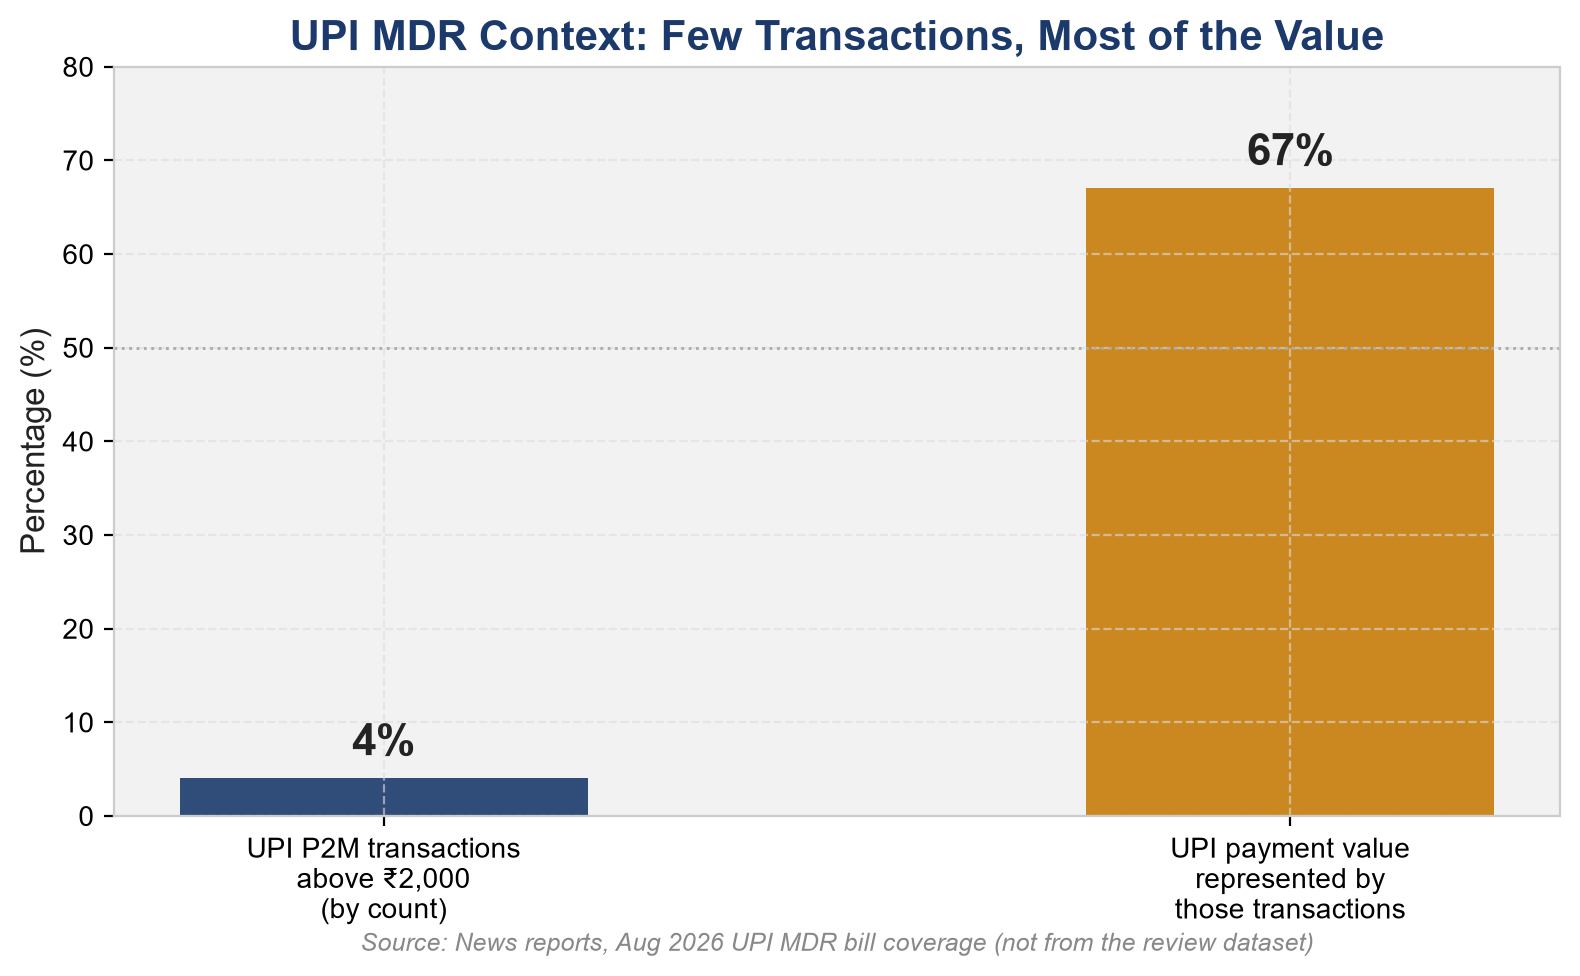

Saved → charts/04_upi_mdr_value_concentration.png


In [9]:
# ── 9c: Market Context — UPI MDR Value Concentration ──────────────────────────────────
fig4, ax_upi = plt.subplots(figsize=(8, 5), dpi=200)

categories = [
    'UPI P2M transactions\nabove ₹2,000\n(by count)',
    'UPI payment value\nrepresented by\nthose transactions'
]
values = [4, 67]
colors = [COLOR_NAVY, COLOR_AMBER]

bars = ax_upi.bar(categories, values, color=colors, width=0.45, alpha=0.9)

# Annotate bars
for bar, val in zip(bars, values):
    ax_upi.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1.5,
                f'{val}%', ha='center', va='bottom',
                fontsize=16, fontweight='bold', color=COLOR_TEXT)

ax_upi.set_title('UPI MDR Context: Few Transactions, Most of the Value',
                 color=COLOR_NAVY, fontsize=15, fontweight='bold')
ax_upi.set_ylabel('Percentage (%)')
ax_upi.set_ylim(0, 80)
ax_upi.axhline(50, color='#AAAAAA', linestyle=':', linewidth=1)
ax_upi.grid(True)
ax_upi.text(0.5, -0.18,
            'Source: News reports, Aug 2026 UPI MDR bill coverage (not from the review dataset)',
            ha='center', transform=ax_upi.transAxes,
            fontsize=9, color='#888888', style='italic')

plt.tight_layout()
plt.savefig('charts/04_upi_mdr_value_concentration.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved → charts/04_upi_mdr_value_concentration.png")


---
## 10. Conclusion

This analysis of **2,400 Google Play reviews** across **PhonePe, Paytm, and CRED** reveals five headline insights — three from the KPI and vocabulary analysis (Sections 5–8), and two from the deeper diagnostics (Section 9):

1. **Paytm and PhonePe are user-satisfaction leaders.** With average ratings of **4.60** and **4.42** respectively, and positive-review rates above 86%, both apps have built strong loyalty. Their VADER average sentiment scores (0.35 and 0.36) are meaningfully higher than the dataset average, confirming that organic praise — not just star-rating gaming — is real.

2. **CRED faces a structural satisfaction crisis.** At a **3.30 average rating** and **39.6% negative review share**, CRED's user sentiment is significantly below the fintech peer benchmark. The concentration of negative language around *cashback, customer support, and worst/useless* indicates that CRED's core value proposition is not being delivered reliably. Without targeted product fixes, rating regression is likely as the user base scales.

3. **The gap is about trust, not features.** CRED's complaints center on broken cashback promises (62 mentions), while Paytm and PhonePe's praise centers on reliable UPI service — so the KPI gap (57% vs 86–91% positive) is driven by reliability, not feature count.

4. **A TF-IDF + Logistic Regression classifier shows review text carries real predictive signal for negativity — but isn't production-ready yet.** Trained on 80% of the binary (Positive/Negative) subset and tested on 20%, the model reaches 90.6% headline accuracy, but that number is inflated by class imbalance: negative-class recall is only 34%, meaning it misses two-thirds of true negative reviews. It's a promising proof of concept for automated triage, not a deployable one, until class-balancing is added.

5. **UPI MDR turns the trust gap into a revenue gap.** From 15 October 2026, merchant UPI payments above ₹2,000 carry a 0.4% MDR — ending six years of zero-fee UPI and creating a new revenue pool concentrated in high-value payments. Users route those payments through apps they trust, so Paytm and PhonePe (4.40–4.60★) are positioned to capture this revenue, while CRED's trust deficit leaves it exposed.

---
*Analysis produced using Python · pandas · VADER Sentiment · scikit-learn · matplotlib*  
*Author: Karishma Mekaliya*